# 兩頻道 Shorts 分析模板（template_two）

適用情境：類別有 2 個頻道（如遊戲、籃球幹片、籃球網紅、Kpop）。
核心檢定：Mann-Whitney U；OLS 含 0/1 channel dummy。

## 0. 參數

In [1]:
# === 參數區 ===========================================================
# 改類別只要改這三行；下方所有 cell 都引用這些變數
CSV_TIMESTAMP = "20260527-064904"      # 改這裡切換不同類別的資料
TARGET_CHANNELS = None                  # None = 全部；或填 list 過濾特定頻道
CATEGORY_NAME = "籃球幹片"               # 用於圖表標題、檔名
# ====================================================================


## 1. 匯入函式庫

In [2]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# 中文字體（macOS 預設沒有 Microsoft 系列，使用 sans-serif 後備）
plt.rcParams['font.sans-serif'] = ['Heiti TC', 'PingFang TC', 'Microsoft JhengHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid")

# 將 _templates/ 加入 sys.path 以便 import content_labeling
TPL_DIR = Path('../../analysis/_templates').resolve()
if str(TPL_DIR) not in sys.path:
    sys.path.insert(0, str(TPL_DIR))

print("✓ 函式庫載入完成")


✓ 函式庫載入完成


## 2. 載入 CSV

In [3]:
# 載入資料（路徑從 analysis/<cat>/ 回退兩層到 final project/）
df = pd.read_csv(f'../../data/processed/channel_videos_{CSV_TIMESTAMP}.csv', encoding='utf-8')
df_channels = pd.read_csv(f'../../data/processed/channels_{CSV_TIMESTAMP}.csv', encoding='utf-8')

if TARGET_CHANNELS is not None:
    df = df[df['channel_title'].isin(TARGET_CHANNELS)].copy()

print(f"✓ 資料載入：{len(df)} 列影片 / {len(df_channels)} 列頻道")
print(f"頻道：{df['channel_title'].unique().tolist()}")


✓ 資料載入：400 列影片 / 2 列頻道
頻道：['卷毛懂个球', '俊鸿TV']


## 3. 檢視資料結構

In [4]:
print(df.dtypes)
print()
print('頻道列表：', df['channel_title'].unique())
print()
print(df.head())


video_id              str
title                 str
description           str
channel_id            str
channel_title         str
published_at          str
category_id         int64
tags                  str
default_language      str
duration_iso          str
duration_sec        int64
definition            str
caption              bool
view_count          int64
like_count          int64
comment_count       int64
favorite_count      int64
topic_categories      str
fetched_at            str
dtype: object

頻道列表： <StringArray>
['卷毛懂个球', '俊鸿TV']
Length: 2, dtype: str

      video_id                       title  \
0  ltpL8JcEf7M    #篮球 #内容过于真实 你遇到这种秒开战斗脸的吗   
1  bG-3V13xlmg       #篮球 #内容过于真实 坏人变老了就老坏了   
2  XIRLk_NblWM       #内容过于真实 #篮球 朋友，你的就是我的   
3  ZnLoUpyUhWg        球场嘴硬现场：口角不断，最后到底谁赢了？   
4  m0Rp0rMgPkQ  #内容过于真实 #篮球 警告大家不要随便和坏老头单挑   

                                         description  \
0  🏀「卷毛懂个球」——野球场真实人类观察实录来啦！  \n\n这里是把篮球场搬进段子工厂的神奇...   
1  🏀「卷毛懂个球」——野球场真实人类观察实录来啦！  \n\n这里是把篮球场搬

## 4. 資料清理與前處理

In [5]:
# 資料清理 + 派生欄位
df_clean = df.copy()
df_clean['published_at'] = pd.to_datetime(df_clean['published_at'])
df_clean['fetched_at'] = pd.to_datetime(df_clean['fetched_at'])

# 標題長度（混合 CJK + 英文之視覺字符數）
df_clean['title_length'] = df_clean['title'].fillna('').apply(len)

# CJK / EN 分開計，跨類別比較時較公平
def count_cjk(s):
    return sum(1 for c in str(s) if '一' <= c <= '鿿')

def count_en_words(s):
    import re
    return len(re.findall(r'[A-Za-z]+', str(s)))

df_clean['title_length_cjk'] = df_clean['title'].fillna('').apply(count_cjk)
df_clean['title_length_en'] = df_clean['title'].fillna('').apply(count_en_words)

# tag_count: 用 flatten_video 的 '|' 串接，注意 NaN
df_clean['tag_count'] = df_clean['tags'].fillna('').apply(lambda s: 0 if not s else len(s.split('|')))

# Shorts 判定（沿用 Reg/02、Reg/03 的 180 秒閾值）
df_shorts = df_clean[df_clean['duration_sec'] <= 180].copy()

print(f"原始：{len(df_clean)}  Shorts (≤180s)：{len(df_shorts)}")
print(f"  每頻道 Shorts 篇數：")
print(df_shorts['channel_title'].value_counts())


原始：400  Shorts (≤180s)：304
  每頻道 Shorts 篇數：
channel_title
俊鸿TV     164
卷毛懂个球    140
Name: count, dtype: int64


## 4.5 內容貼標（Layer 1-3）

In [6]:
# === §4.5 內容貼標（Layer 1-3） ============================
# 此 cell 由 content_labeling.py 注入
import content_labeling as cl

df_with_topics, topic_counts = cl.explode_topic_categories(df_shorts)
df_lab = cl.apply_keyword_labels(df_with_topics, text_cols=("title", "tags"))
buckets = cl.load_keyword_dict()
label_cols = [f"has_{b}" for b in buckets]

print("Layer 1 — topic 全體計數 (Top 15)：")
print(topic_counts.head(15))
print()

topic_dist = cl.topic_distribution_by_channel(df_with_topics)
print("Layer 1 — 頻道 × topic 比例：")
print(topic_dist)
print()

print("Layer 2 — 規則式關鍵字命中率（按頻道）：")
print(df_lab.groupby('channel_title')[label_cols].mean().round(3))
print()

try:
    tfidf = cl.tfidf_top_keywords_by_channel(df_lab, n=15)
    print("Layer 3 — TF-IDF Top 15 keywords / channel：")
    for ch, kws in tfidf.items():
        print(f"\n{ch}:")
        for kw, sc in kws:
            print(f"  {kw:20s}  {sc:.4f}")
except RuntimeError as e:
    print(f"Layer 3 跳過：{e}")


Building prefix dict from the default dictionary ...


Loading model from cache /var/folders/wy/8m1lyrld379571szqbz_htvw0000gn/T/jieba.cache


Layer 1 — topic 全體計數 (Top 15)：
Basketball               243
Sport                    199
Humour                    49
Lifestyle_(sociology)     49
Entertainment             47
Video_game_culture         8
Baseball                   6
Film                       2
dtype: int64

Layer 1 — 頻道 × topic 比例：
       Basketball     Sport  Lifestyle_(sociology)  Entertainment    Humour  \
俊鸿TV     0.902439  0.865854               0.079268       0.048780  0.042683   
卷毛懂个球    0.678571  0.407143               0.257143       0.278571  0.300000   

       Baseball      Film  Video_game_culture  
俊鸿TV   0.006098  0.012195            0.000000  
卷毛懂个球  0.035714  0.000000            0.057143  

Layer 2 — 規則式關鍵字命中率（按頻道）：
               has_教學教育  has_挑戰對決  has_搞笑迷因  has_開箱評測  has_互動誘導  has_情緒詞  \
channel_title                                                              
俊鸿TV              0.122     0.049     0.652       0.0       0.0    0.037   
卷毛懂个球             0.007     0.000     0.679       0.0       0

Loading model cost 0.228 seconds.


Prefix dict has been built successfully.


Layer 3 — TF-IDF Top 15 keywords / channel：

俊鸿TV:
  回顧                    0.5678
  往期                    0.5678
  野球                    0.2028
  球場                    0.1926
  籃球                    0.1115
  一個                    0.1115
  隊友                    0.0913
  打球                    0.0866
  真正                    0.0811
  兄弟                    0.0794
  自己                    0.0721
  時刻                    0.0710
  高手                    0.0710
  有料                    0.0710
  教學                    0.0710

卷毛懂个球:
  兄弟                    0.3045
  打球                    0.2664
  就是                    0.2140
  遇到                    0.2093
  还是                    0.1872
  身边                    0.1872
  打篮球                   0.1872
  你们                    0.1605
  小时候                   0.1337
  特别                    0.1337
  我要                    0.1337
  时候                    0.1337
  这种                    0.1337
  一个                    0.1337
  篮球                    0.1142


## 5. 描述性統計

In [7]:
# 描述性統計
metrics = ['view_count', 'like_count', 'comment_count', 'duration_sec',
           'title_length', 'tag_count']
print("Shorts 主要指標統計：")
for m in metrics:
    if m in df_shorts.columns:
        d = df_shorts[m].dropna()
        if len(d) == 0:
            continue
        print(f"  {m:15s} mean={d.mean():>12,.1f}  median={d.median():>10,.1f}  std={d.std():>12,.1f}")

# 頻道級摘要
print("\n每頻道摘要：")
agg = df_shorts.groupby('channel_title').agg(
    n_shorts=('video_id', 'count'),
    mean_view=('view_count', 'mean'),
    median_view=('view_count', 'median'),
    mean_like=('like_count', 'mean'),
    mean_comment=('comment_count', 'mean'),
)
print(agg)


Shorts 主要指標統計：
  view_count      mean=    76,862.4  median=  21,015.0  std=   128,964.8
  like_count      mean=     1,776.6  median=     542.0  std=     2,989.4
  comment_count   mean=         9.5  median=       4.0  std=        19.5
  duration_sec    mean=        95.2  median=      94.5  std=        45.9
  title_length    mean=        46.3  median=      43.5  std=        21.2
  tag_count       mean=        21.6  median=      20.0  std=        11.6

每頻道摘要：
               n_shorts      mean_view  median_view    mean_like  mean_comment
channel_title                                                                 
俊鸿TV                164  120376.036585      42412.0  2815.262195     14.018293
卷毛懂个球               140   25889.385714      10578.0   559.835714      4.164286


## 6. 兩頻道差異檢定（Mann-Whitney U）

In [8]:
from scipy.stats import mannwhitneyu

chs = sorted(df_shorts['channel_title'].unique())
if len(chs) != 2:
    print(f"⚠ 頻道數 = {len(chs)}，非 two-channel；請改用其他模板或在 TARGET_CHANNELS 限縮")
else:
    ch1, ch2 = chs
    g1 = df_shorts[df_shorts['channel_title']==ch1]
    g2 = df_shorts[df_shorts['channel_title']==ch2]
    print(f"{ch1}: n={len(g1)}    {ch2}: n={len(g2)}")
    for m in ['view_count','like_count','comment_count','title_length','tag_count']:
        a = g1[m].dropna(); b = g2[m].dropna()
        if len(a) > 0 and len(b) > 0:
            u, p = mannwhitneyu(a, b, alternative='two-sided')
            sig = "***" if p<.001 else "**" if p<.01 else "*" if p<.05 else "ns"
            print(f"  {m:15s} {ch1}={a.mean():>12,.1f}  {ch2}={b.mean():>12,.1f}  p={p:.4e} {sig}")


俊鸿TV: n=164    卷毛懂个球: n=140
  view_count      俊鸿TV=   120,376.0  卷毛懂个球=    25,889.4  p=2.1199e-19 ***
  like_count      俊鸿TV=     2,815.3  卷毛懂个球=       559.8  p=1.1658e-20 ***
  comment_count   俊鸿TV=        14.0  卷毛懂个球=         4.2  p=3.1290e-11 ***
  title_length    俊鸿TV=        62.3  卷毛懂个球=        27.6  p=2.1626e-46 ***
  tag_count       俊鸿TV=        28.5  卷毛懂个球=        13.4  p=7.0216e-46 ***


## 7. 發佈時間趨勢

In [9]:
# 發佈時間特徵
df_shorts['pub_date'] = df_shorts['published_at'].dt.date
df_shorts['pub_hour'] = df_shorts['published_at'].dt.hour
df_shorts['pub_day_of_week'] = df_shorts['published_at'].dt.day_name()
df_shorts['pub_hour_band'] = pd.cut(df_shorts['pub_hour'], bins=[-1,5,11,17,21,24],
                                     labels=['深夜','早','中','下','晚'])

# 按小時
print("按發佈時段平均觀看數：")
print(df_shorts.groupby('pub_hour_band', observed=False)['view_count'].mean().round(0))


按發佈時段平均觀看數：
pub_hour_band
深夜    70002.0
早     91873.0
中     53765.0
下     80060.0
晚     66340.0
Name: view_count, dtype: float64


## 7.1 相關性分析

In [10]:
# 相關性分析
analysis_cols = ['view_count', 'like_count', 'comment_count', 'duration_sec',
                 'title_length', 'tag_count']
corr = df_shorts[analysis_cols].corr()
print("相關係數矩陣：")
print(corr.round(3))

print("\n與 view_count 的相關性顯著性檢定（Pearson）：")
for col in ['like_count', 'comment_count', 'duration_sec', 'title_length', 'tag_count']:
    d = df_shorts[[col, 'view_count']].dropna()
    if len(d) > 2:
        r, p = stats.pearsonr(d[col], d['view_count'])
        sig = "***" if p<.001 else "**" if p<.01 else "*" if p<.05 else "ns"
        print(f"  {col:15s} r={r:+.4f}  p={p:.4e} {sig}")


相關係數矩陣：
               view_count  like_count  comment_count  duration_sec  \
view_count          1.000       0.980          0.818         0.292   
like_count          0.980       1.000          0.859         0.331   
comment_count       0.818       0.859          1.000         0.271   
duration_sec        0.292       0.331          0.271         1.000   
title_length        0.368       0.372          0.239         0.163   
tag_count           0.007      -0.007         -0.159        -0.134   

               title_length  tag_count  
view_count            0.368      0.007  
like_count            0.372     -0.007  
comment_count         0.239     -0.159  
duration_sec          0.163     -0.134  
title_length          1.000      0.543  
tag_count             0.543      1.000  

與 view_count 的相關性顯著性檢定（Pearson）：
  like_count      r=+0.9803  p=9.6008e-215 ***
  comment_count   r=+0.8178  p=1.8852e-74 ***
  duration_sec    r=+0.2920  p=2.1822e-07 ***
  title_length    r=+0.3676  p=3.6830e-11

## 7.5 內容標籤與觀看數的關係

In [11]:
# === §7.5 內容標籤與觀看數的關係 ==========================
# 此 cell 由 content_labeling.py 注入：卡方 + logistic
from scipy.stats import chi2_contingency
import statsmodels.formula.api as smf

# 高觀看 = top quartile（每頻道內或整體）
view_q3 = df_lab['view_count'].quantile(0.75)
df_lab['top_quartile'] = (df_lab['view_count'] >= view_q3).astype(int)

print(f"top_quartile 門檻：view_count >= {view_q3:,.0f}")
print()

print("每個 label vs 高觀看 卡方檢定：")
for col in label_cols:
    if df_lab[col].sum() < 5 or df_lab[col].sum() > len(df_lab) - 5:
        print(f"  {col:25s} (樣本太集中, 跳過)")
        continue
    tab = pd.crosstab(df_lab[col], df_lab['top_quartile'])
    chi2, p, _, _ = chi2_contingency(tab)
    sig = "***" if p<.001 else "**" if p<.01 else "*" if p<.05 else "ns"
    print(f"  {col:25s} chi2={chi2:6.2f}  p={p:.4e} {sig}")

# Logistic：P(top_quartile) ~ has_*
formula = "top_quartile ~ " + " + ".join(label_cols)
try:
    model = smf.logit(formula=formula, data=df_lab).fit(disp=False)
    print("\nLogistic 迴歸：")
    print(model.summary())
except Exception as e:
    print(f"\nLogistic 跳過：{e}")


top_quartile 門檻：view_count >= 82,352

每個 label vs 高觀看 卡方檢定：
  has_教學教育                  chi2=  2.06  p=1.5090e-01 ns
  has_挑戰對決                  chi2=  4.28  p=3.8580e-02 *
  has_搞笑迷因                  chi2=  3.86  p=4.9574e-02 *
  has_開箱評測                  (樣本太集中, 跳過)
  has_互動誘導                  (樣本太集中, 跳過)
  has_情緒詞                   chi2=  0.17  p=6.7907e-01 ns
  has_品牌推廣                  (樣本太集中, 跳過)
  has_食物                    (樣本太集中, 跳過)
  has_運動                    chi2= 21.04  p=4.5086e-06 ***
  has_問句                    chi2=  2.06  p=1.5135e-01 ns

Logistic 跳過：Singular matrix


## 8. Top 10 視覺化

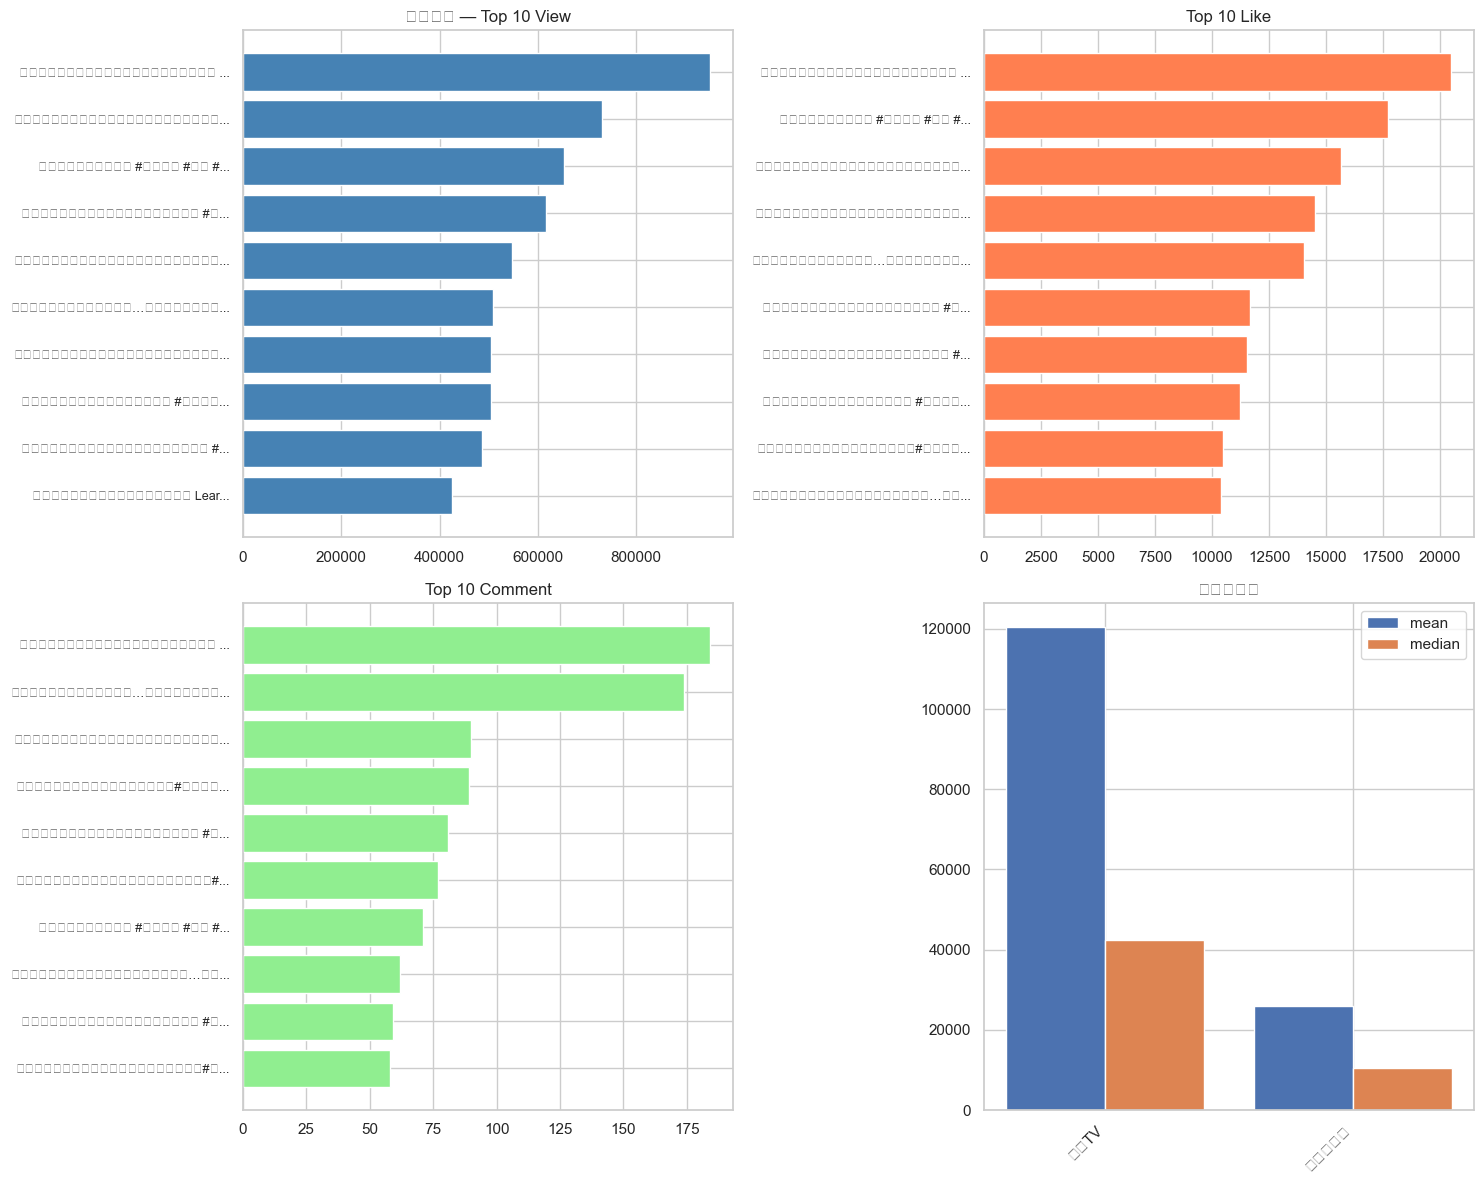

In [12]:
# Top 10 視覺化
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

t10v = df_shorts.nlargest(10, 'view_count')
axes[0,0].barh(range(len(t10v)), t10v['view_count'].values, color='steelblue')
axes[0,0].set_yticks(range(len(t10v)))
axes[0,0].set_yticklabels([f"{t[:22]}..." if len(str(t))>22 else str(t) for t in t10v['title']], fontsize=9)
axes[0,0].set_title(f'{CATEGORY_NAME} — Top 10 View'); axes[0,0].invert_yaxis()

t10l = df_shorts.nlargest(10, 'like_count')
axes[0,1].barh(range(len(t10l)), t10l['like_count'].values, color='coral')
axes[0,1].set_yticks(range(len(t10l)))
axes[0,1].set_yticklabels([f"{t[:22]}..." if len(str(t))>22 else str(t) for t in t10l['title']], fontsize=9)
axes[0,1].set_title('Top 10 Like'); axes[0,1].invert_yaxis()

t10c = df_shorts.nlargest(10, 'comment_count')
axes[1,0].barh(range(len(t10c)), t10c['comment_count'].values, color='lightgreen')
axes[1,0].set_yticks(range(len(t10c)))
axes[1,0].set_yticklabels([f"{t[:22]}..." if len(str(t))>22 else str(t) for t in t10c['title']], fontsize=9)
axes[1,0].set_title('Top 10 Comment'); axes[1,0].invert_yaxis()

ch_summary = df_shorts.groupby('channel_title')['view_count'].agg(['mean','median']).reset_index()
x = range(len(ch_summary))
axes[1,1].bar([i-0.2 for i in x], ch_summary['mean'], 0.4, label='mean')
axes[1,1].bar([i+0.2 for i in x], ch_summary['median'], 0.4, label='median')
axes[1,1].set_xticks(list(x))
axes[1,1].set_xticklabels(ch_summary['channel_title'], rotation=45, ha='right')
axes[1,1].set_title('頻道觀看數'); axes[1,1].legend()

plt.tight_layout(); plt.show()


## 9. 迴歸：兩條 OLS 線 + channel dummy

In [13]:
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

df_reg = df_shorts[['view_count','duration_sec','title_length','tag_count','channel_title']].dropna()
print(f"迴歸樣本數：{len(df_reg)}")

if len(df_reg) >= 10:
    scaler = StandardScaler()
    feats = ['duration_sec','title_length','tag_count']
    dfs = df_reg.copy()
    dfs[feats] = scaler.fit_transform(df_reg[feats])

    m1 = smf.ols('view_count ~ duration_sec + title_length + tag_count', data=dfs).fit()
    m2 = smf.ols('view_count ~ duration_sec + title_length + tag_count + C(channel_title)', data=dfs).fit()
    print("Model 1（無 channel dummy）：")
    print(m1.summary())
    print("\nModel 2（含 channel dummy）：")
    print(m2.summary())
    print(f"\nM1 R²={m1.rsquared:.4f}  Adj R²={m1.rsquared_adj:.4f}")
    print(f"M2 R²={m2.rsquared:.4f}  Adj R²={m2.rsquared_adj:.4f}")

    X = m1.model.exog
    names = m1.model.exog_names
    vif = pd.DataFrame({"Variable": names[1:],
                        "VIF": [variance_inflation_factor(X, i) for i in range(1, X.shape[1])]})
    print("\nVIF：")
    print(vif.to_string(index=False))
else:
    print("樣本太少，跳過迴歸")


迴歸樣本數：304
Model 1（無 channel dummy）：
                            OLS Regression Results                            
Dep. Variable:             view_count   R-squared:                       0.220
Model:                            OLS   Adj. R-squared:                  0.213
Method:                 Least Squares   F-statistic:                     28.28
Date:                Wed, 27 May 2026   Prob (F-statistic):           3.92e-16
Time:                        14:55:15   Log-Likelihood:                -3970.3
No. Observations:                 304   AIC:                             7949.
Df Residuals:                     300   BIC:                             7963.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept   

## 10. 散布圖 + 回歸線（依 channel 著色）

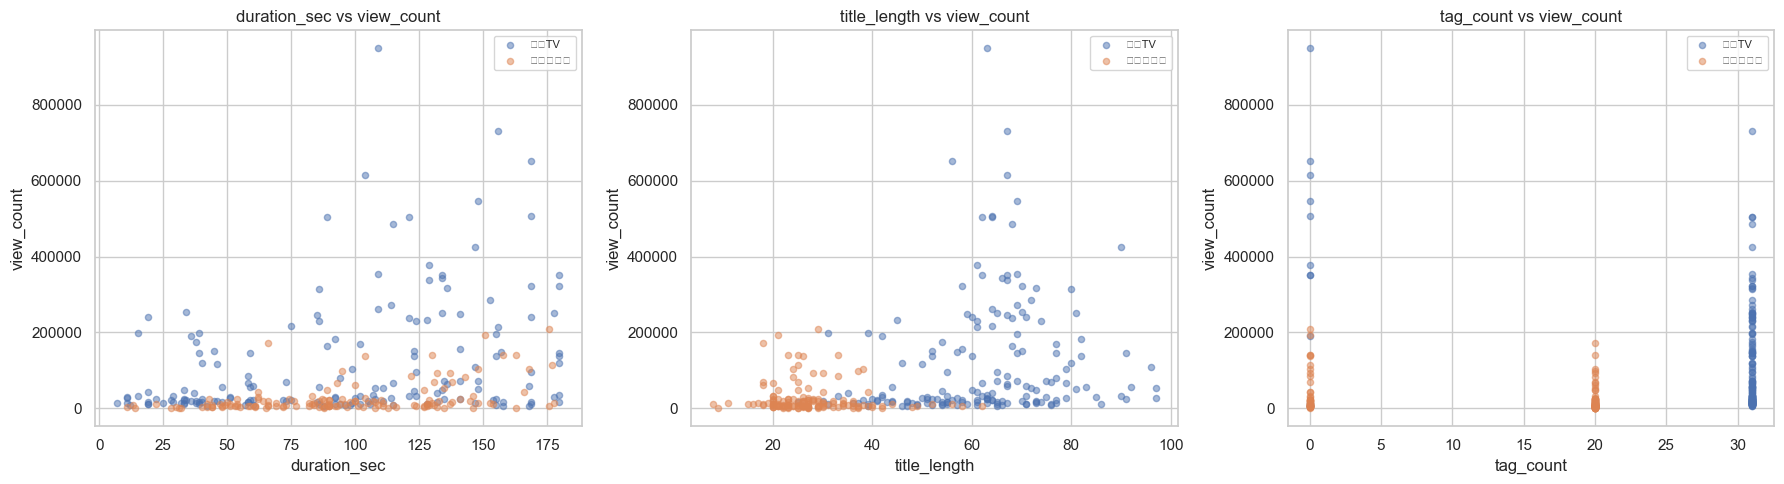

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, x_col in zip(axes, ['duration_sec','title_length','tag_count']):
    for ch, g in df_shorts.groupby('channel_title'):
        ax.scatter(g[x_col], g['view_count'], alpha=0.5, label=ch, s=20)
    ax.set_xlabel(x_col); ax.set_ylabel('view_count')
    ax.set_title(f'{x_col} vs view_count'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


## 11. 結論

（依分析結果手動撰寫）